In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

import warnings
warnings.filterwarnings('ignore')

In [52]:
iris = load_iris()
df = pd.DataFrame(iris.data, iris.target, columns = iris.feature_names)
df['Target'] = iris.target

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150 entries, 0 to 2
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   Target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 7.0 KB


In [54]:
df.shape

(150, 5)

In [55]:
# Check null values
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
Target               0
dtype: int64

In [56]:
# check duplicated rows
df.duplicated().sum()
df.drop_duplicates(inplace = True)
df.duplicated().sum()

np.int64(0)

In [57]:
numerical_features = df.select_dtypes(include = 'number')

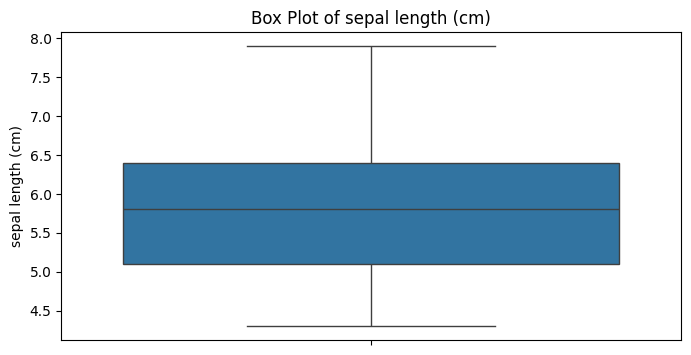

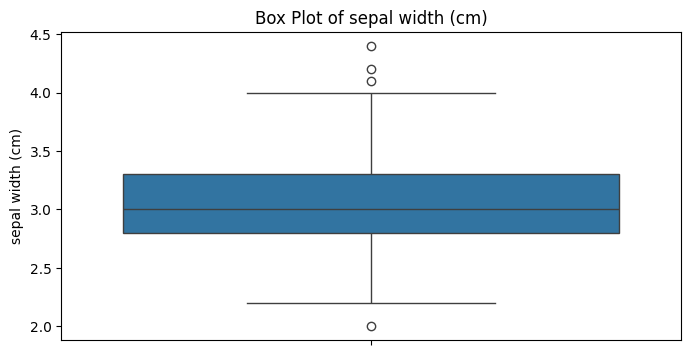

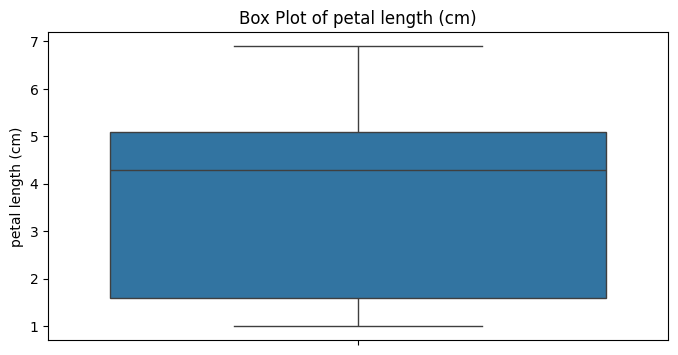

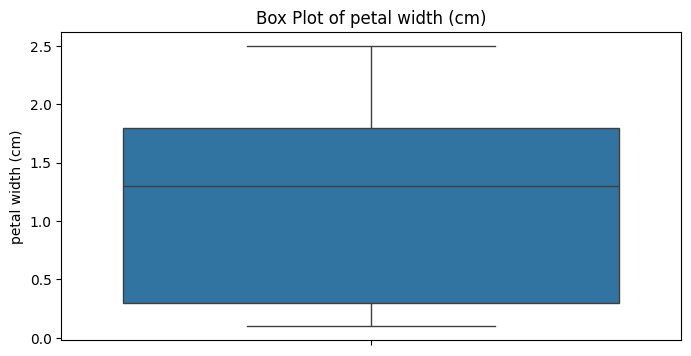

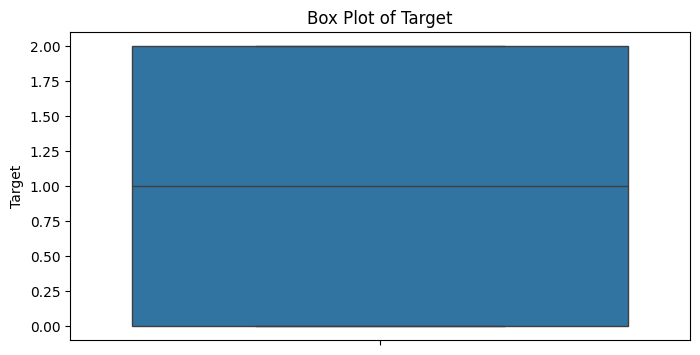

In [58]:
# Box Plot For each Numerical Feature Before Handling Outliers

for feature in df:
    plt.figure(figsize = (8, 4))
    sns.boxplot(df[feature])
    plt.title(f'Box Plot of {feature}')

In [59]:
def handle_outliers(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        upper_bound = Q3 + 1.5 * IQR
        lower_bound = Q1 - 1.5 * IQR

        # Trimming Outliers
        # df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

        # Capping Outliers
        df.loc[df[col] > upper_bound, col] = upper_bound
        df.loc[df[col] < lower_bound, col] = lower_bound

    return df

handle_outliers(df, numerical_features)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Target
0,5.1,3.5,1.4,0.2,0
0,4.9,3.0,1.4,0.2,0
0,4.7,3.2,1.3,0.2,0
0,4.6,3.1,1.5,0.2,0
0,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
2,6.7,3.0,5.2,2.3,2
2,6.3,2.5,5.0,1.9,2
2,6.5,3.0,5.2,2.0,2
2,6.2,3.4,5.4,2.3,2


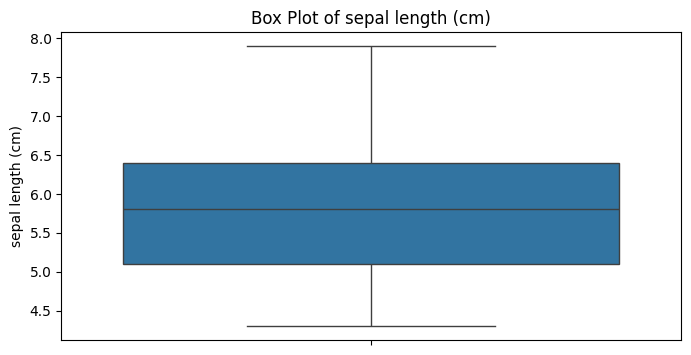

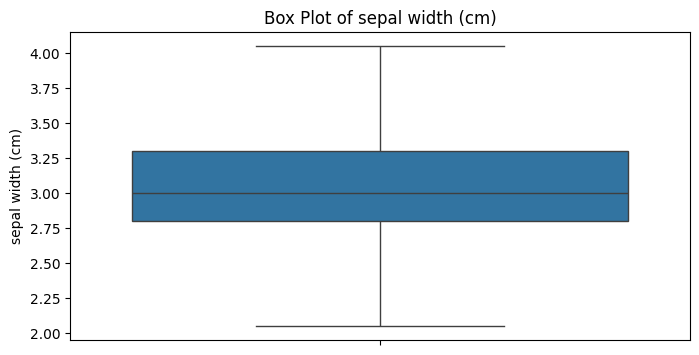

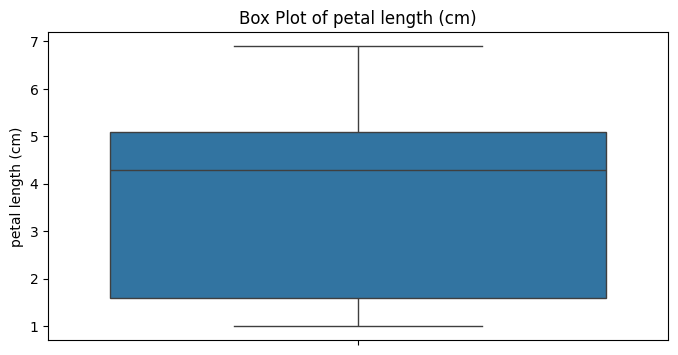

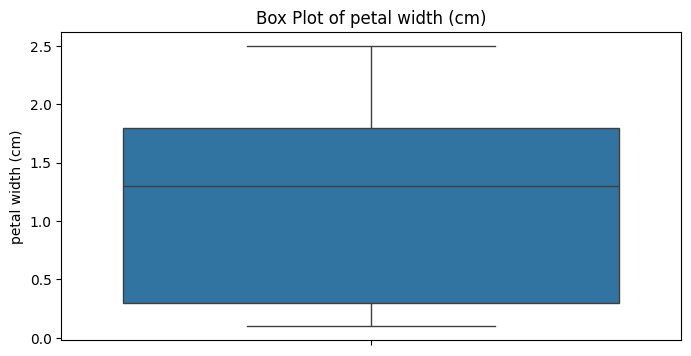

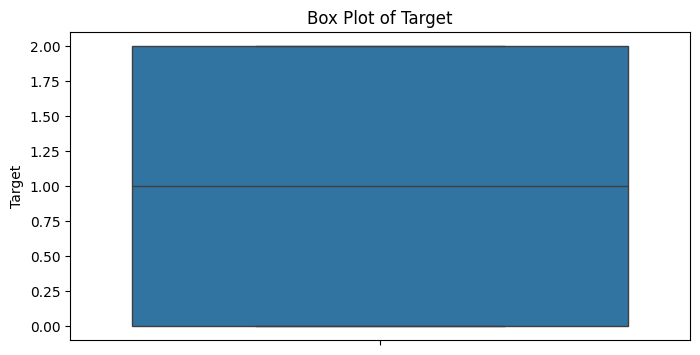

In [60]:
# check for outliers again

for feature in df:
    plt.figure(figsize = (8, 4))
    sns.boxplot(df[feature])
    plt.title(f'Box Plot of {feature}')

<Axes: >

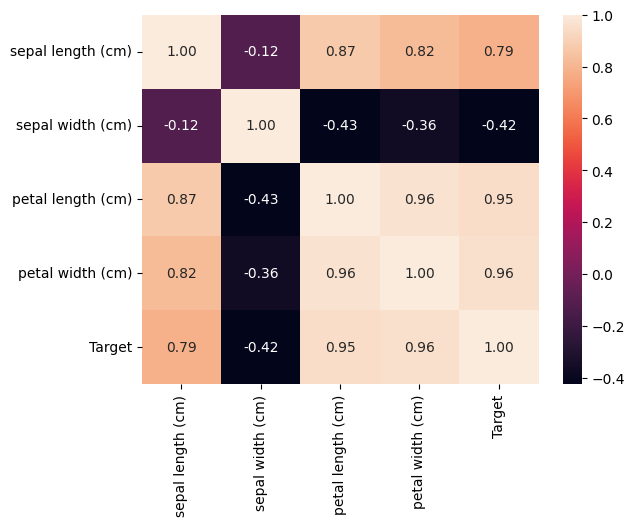

In [61]:
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot = True, fmt = ".2f")

In [62]:
X = df.drop(columns = 'Target', axis = 1)
y = df['Target']

In [63]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

print(f"Train set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")

Train set: 119 samples
Test set: 30 samples


In [67]:
# K-Nearest Neighbours
knn = KNeighborsClassifier()

param_grid = {
    'n_neighbors' : [5, 3, 7, 9]
}

grid_search = GridSearchCV(knn, param_grid, cv = 5, scoring='accuracy')
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)

best_knn = grid_search.best_estimator_
r2_score_test = best_knn.score(X_test, y_test)
print("Test Set Accuracy:", r2_score_test)

Best Parameters: {'n_neighbors': 3}
Test Set Accuracy: 0.9666666666666667
